<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/YB_0403(2)_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [ ]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print("오차 행렬:\n", cm)

오차 행렬:
 [[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**





- 정확도: 전체 예측 데이터 중 모델이 올바르게 예측한(True Positive + True Negative) 데이터의 비율
- 모델이 양성과 악성을 전반적으로 얼마나 잘 맞추고 있는지 직관적인 성능을 보여줌. 단, 데이터 불균형이 심할 때는(예: 암 환자가 1%밖에 없는 경우) 정확도만 보면 성능을 착각할 수 있음.

In [ ]:
from sklearn.metrics import accuracy_score

print(f"정확도: {accuracy_score(y, y_pred):.4f}")

정확도: 0.9121


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**


- 예측을 Positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율
- 양성(0)인 환자를 악성(1)으로 잘못 예측하면 안 되는 경우에 중요. 거짓 양성(False Positive)을 줄여야 할 때 눈여겨봐야 하는 지표

In [ ]:
from sklearn.metrics import precision_score

print(f"정밀도: {precision_score(y, y_pred):.4f}")

정밀도: 0.9010


**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

- 실제 Positive(악성, 1)인 데이터 중에서 모델이 Positive로 올바르게 예측한 비율
- 암 진단 데이터에서 가장 중요한 지표. 실제 악성(1)인 환자를 양성(0)으로 잘못 판단해 놓치면(False Negative) 생명에 치명적이므로, 재현율을 높이는 것이 아주 중요

In [ ]:
from sklearn.metrics import recall_score

print(f"재현율: {recall_score(y, y_pred):.4f}")

재현율: 0.8585


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**
- 정밀도와 재현율의 조화평균
- 정밀도와 재현율이 어느 한쪽으로 치우치지 않는지 나타내며, 양성과 악성 데이터 비율이 불균형할 때 모델의 실질적인 성능을 평가하기 가장 좋은 지표

In [ ]:
from sklearn.metrics import f1_score

print(f"F1 Score: {f1_score(y, y_pred):.4f}")

F1 Score: 0.8792


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [ ]:
from sklearn.preprocessing import Binarizer

# 모델의 예측 확률 추출 (양성일 확률, 악성일 확률)
pred_proba = model_lor.predict_proba(X)

# 악성(1)으로 예측할 확률만 추출 (두 번째 열)
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

# 임계값을 0.9로 설정 (1이 될 확률이 0.9 이상이어야 1로 판정)
binarizer = Binarizer(threshold=0.9)
y_pred2 = binarizer.fit_transform(pred_proba_1)

In [ ]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
print("혼동행렬:\n", confusion_matrix(y, y_pred2))
print(f"정확도: {accuracy_score(y, y_pred2):.4f}")
print(f"정밀도: {precision_score(y, y_pred2):.4f}")
print(f"재현율: {recall_score(y, y_pred2):.4f}")
print(f"F1 Score: {f1_score(y, y_pred2):.4f}")

혼동행렬:
 [[356   1]
 [ 73 139]]
정확도: 0.8699
정밀도: 0.9929
재현율: 0.6557
F1 Score: 0.7898


**ROC 곡선 시각화**

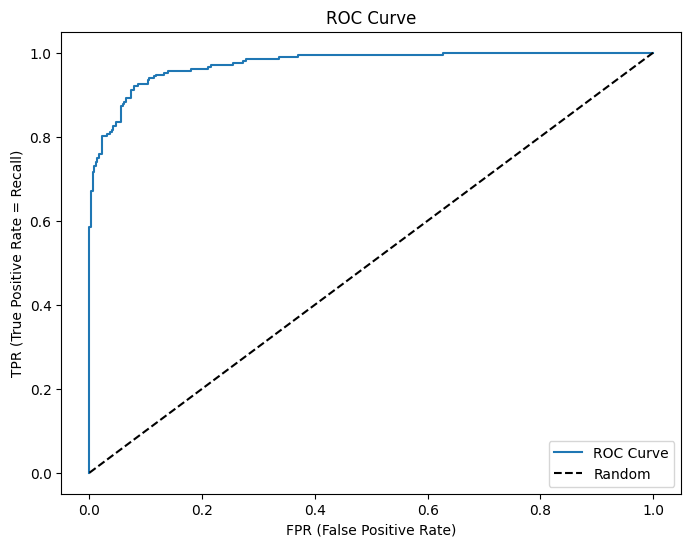

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# FPR, TPR, 임계값 도출
fpr, tpr, thresholds = roc_curve(y, pred_proba[:, 1])

# ROC 곡선 그리기
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random') # 가운데 대각선(랜덤 모델)

plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate = Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [ ]:
from sklearn.metrics import roc_auc_score

print(f"ROC AUC: {roc_auc_score(y, pred_proba[:, 1]):.4f}")

ROC AUC: 0.9741
